In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
df = pd.read_excel(r"C:\Users\HP\Downloads\online+retail+ii\online_retail_II.xlsx")

In [17]:
df.shape

(525461, 8)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
 8   revenue      525461 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 36.1+ MB


In [55]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'revenue'],
      dtype='object')

In [22]:
df.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [24]:
df['revenue'] = df['Quantity'] * df['Price']

In [30]:
print(f"Total Revenue: {df['revenue'].sum()}")

Total Revenue: 9539484.634


In [31]:
df['revenue'].describe()

count    525461.000000
mean         18.154506
std         160.333083
min      -53594.360000
25%           3.750000
50%           9.950000
75%          17.700000
max       25111.090000
Name: revenue, dtype: float64

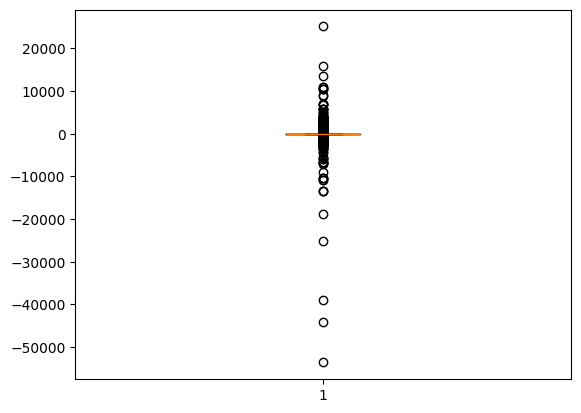

In [32]:
plt.boxplot(df['revenue'])
plt.show()

In [33]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
revenue             0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(6865)

In [36]:
(df['Quantity']<0).sum()

np.int64(12326)

In [ ]:
df[df['Quantity']<0].head()

# gives the return or cancelled quantities

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,revenue
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,-35.4
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,-9.9
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,-17.0
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,-12.6
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,-35.4


In [39]:
(df['Price']==0).sum()

np.int64(3687)

In [40]:
(df['Price']<0).sum()

np.int64(3)

In [42]:
df[df['Price']<0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,revenue
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom,-53594.36
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom,-44031.79
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom,-38925.87


In [43]:
df['Customer ID'].nunique()

4383

In [45]:
print(f"Total Unique Products: {df['StockCode'].nunique()}")

Total Unique Products: 4632


In [48]:
print(f"Start: {df['InvoiceDate'].min()}")
print(f"LAST: {df['InvoiceDate'].max()}")

Start: 2009-12-01 07:45:00
LAST: 2010-12-09 20:01:00


In [52]:
print(f"Positive Revenue : {(df['revenue']>0).sum()}")
print(f"Negative Revenue: {(df['revenue']<0).sum()}")
print(f"Zero Revenue: {(df['revenue']==0).sum()}")

Positive Revenue : 511566
Negative Revenue: 10208
Zero Revenue: 3687


In [58]:
df = df.dropna(subset = ["Customer ID"])

In [59]:
df.shape

(417534, 9)

In [61]:
df["Customer ID"].isnull().sum()

np.int64(0)

In [62]:
df = df.dropna(subset= ["Description"])

In [63]:
df.shape

(417534, 9)

In [64]:
df["Description"].isnull().sum()

np.int64(0)

In [65]:
df["Is Return"] = df["Quantity"]<0

In [69]:
df["Is Return"].value_counts()

Is Return
False    407695
True       9839
Name: count, dtype: int64

In [72]:
sales_df = df[df["Quantity"]>0].copy()

In [73]:
sales_df["Quantity"].min()

np.int64(1)

In [74]:
sales_df.shape

(407695, 10)

In [75]:
sales_df = sales_df[sales_df["Price"]>0].copy()

In [77]:
sales_df["Price"].describe()

count    407664.000000
mean          3.294438
std          34.757965
min           0.001000
25%           1.250000
50%           1.950000
75%           3.750000
max       10953.500000
Name: Price, dtype: float64

In [78]:
sales_df["revenue"]= sales_df["Quantity"] * sales_df["Price"]

In [79]:
sales_df["revenue"].describe()

count    407664.000000
mean         21.664909
std          77.150058
min           0.001000
25%           4.950000
50%          11.900000
75%          19.500000
max       15818.400000
Name: revenue, dtype: float64

In [80]:
sales_df.duplicated().sum()

np.int64(6748)

In [81]:
print(f"Total Sales Revenue: {sales_df["revenue"].sum()}")

Total Sales Revenue: 8832003.274


In [82]:
print(f"Total Units Sold: {sales_df["Quantity"].sum()}")

Total Units Sold: 5538354


In [83]:
print(f"Total Unq Customers: {sales_df["Customer ID"].nunique()}")

Total Unq Customers: 4312


In [85]:
sales_df['date'] = sales_df['InvoiceDate'].dt.date

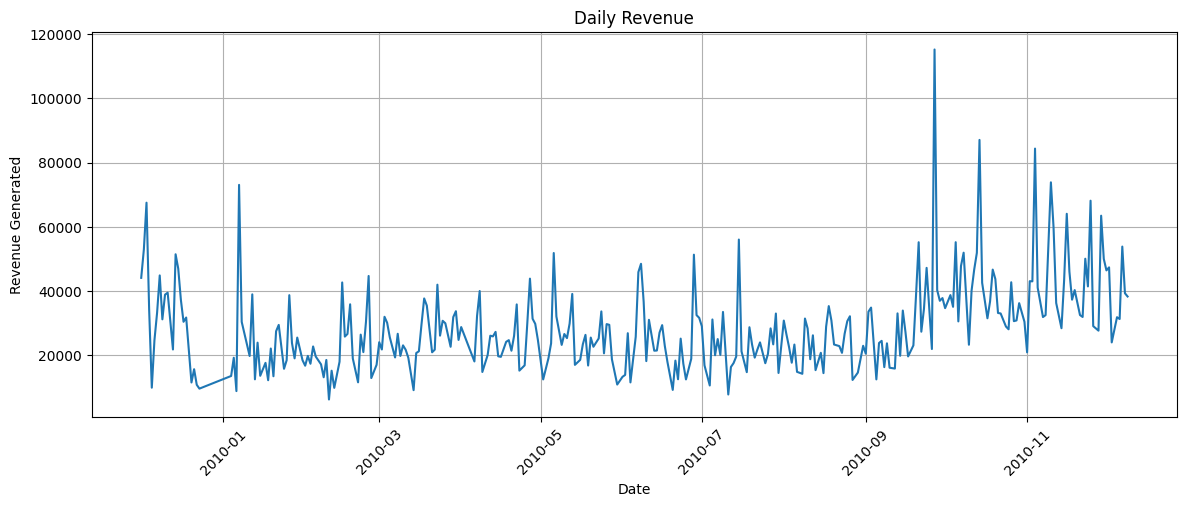

In [89]:
daily_revenue=sales_df.groupby("date")['revenue'].sum()

plt.figure(figsize=(14,5))
plt.plot(daily_revenue.index, daily_revenue.values)

plt.xlabel("Date")
plt.ylabel("Revenue Generated")
plt.title("Daily Revenue")

plt.xticks(rotation=45)
plt.grid()
plt.show()

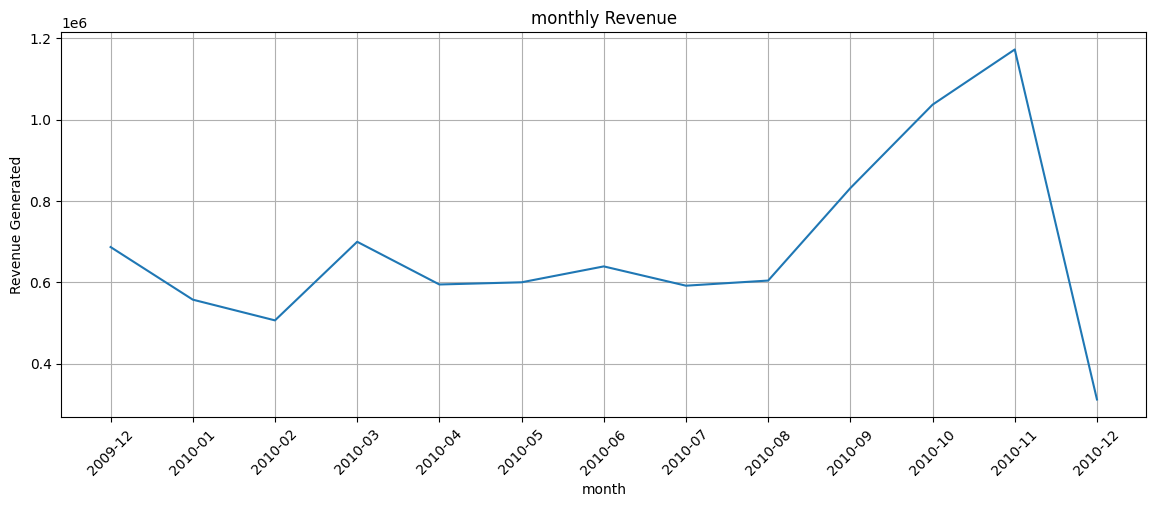

In [91]:
sales_df['month'] = sales_df['InvoiceDate'].dt.to_period('M')

monthly_revenue=sales_df.groupby("month")['revenue'].sum()

plt.figure(figsize=(14,5))
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values)

plt.xlabel("month")
plt.ylabel("Revenue Generated")
plt.title("monthly Revenue")

plt.xticks(rotation=45)
plt.grid()
plt.show()

In [92]:
top_products = sales_df.groupby('Description')['revenue'].sum().sort_values(ascending=False).head(10)
top_products

Description
WHITE HANGING HEART T-LIGHT HOLDER     151624.31
REGENCY CAKESTAND 3 TIER               143893.35
Manual                                  98560.64
ASSORTED COLOUR BIRD ORNAMENT           70493.83
JUMBO BAG RED RETROSPOT                 51759.30
POSTAGE                                 48741.08
ROTATING SILVER ANGELS T-LIGHT HLDR     40186.65
PAPER CHAIN KIT 50'S CHRISTMAS          36933.50
PARTY BUNTING                           35035.90
EDWARDIAN PARASOL NATURAL               34044.75
Name: revenue, dtype: float64

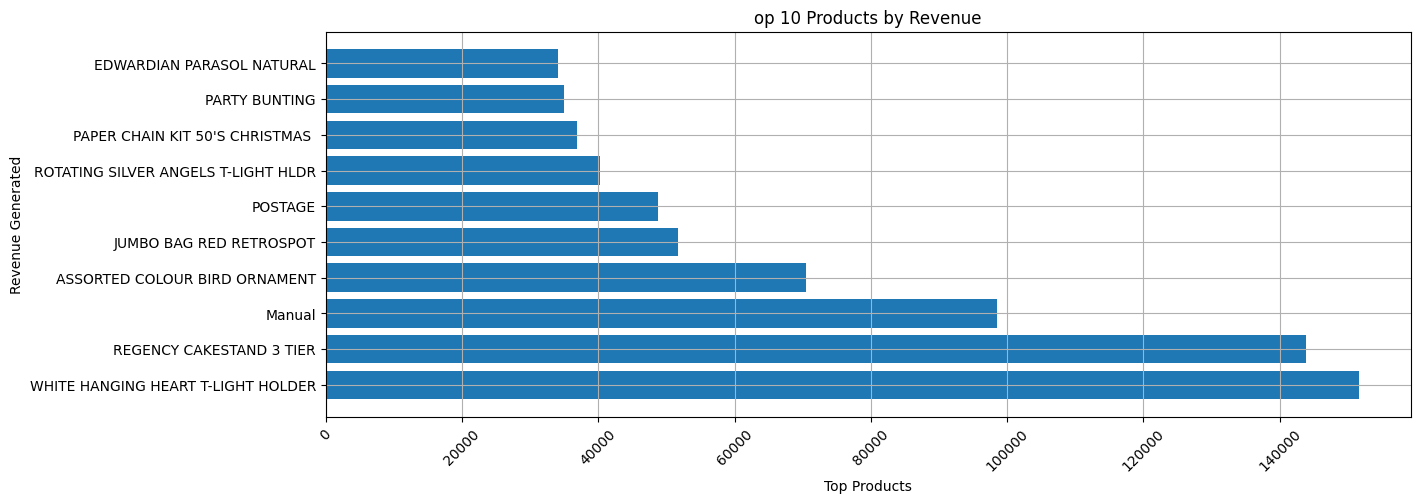

In [94]:
plt.figure(figsize=(14,5))

plt.barh(top_products.index, top_products.values)

plt.xlabel("Top Products")
plt.ylabel("Revenue Generated")
plt.title("op 10 Products by Revenue")

plt.xticks(rotation=45)
plt.grid()
plt.show()

In [97]:
top_countries = sales_df.groupby('Country')['revenue'].sum().sort_values(ascending=False).head()
top_countries

Country
United Kingdom    7414755.963
EIRE               356085.210
Netherlands        268786.000
Germany            202395.321
France             146215.420
Name: revenue, dtype: float64

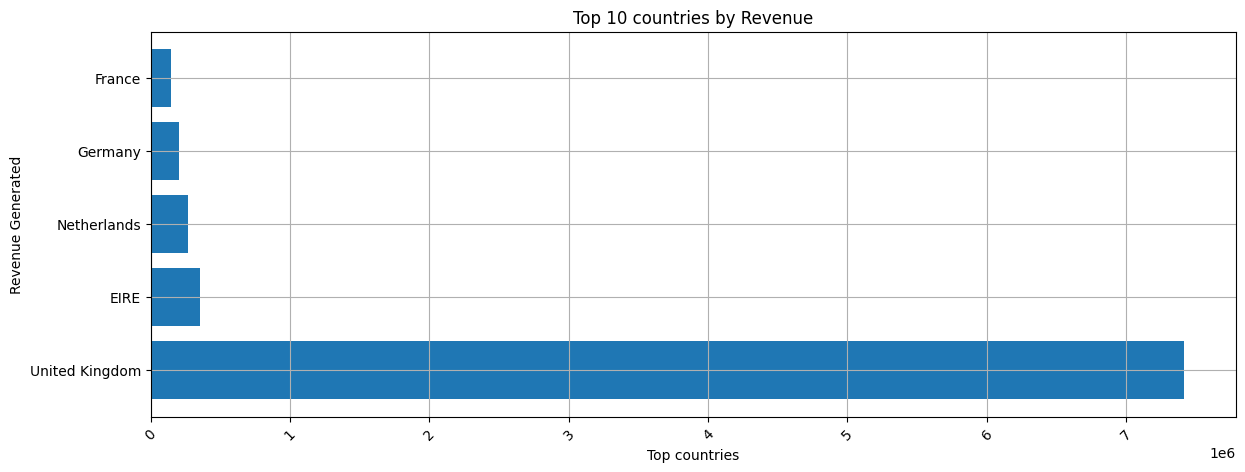

In [100]:
plt.figure(figsize=(14,5))

plt.barh(top_countries.index, top_countries.values)

plt.xlabel("Top countries")
plt.ylabel("Revenue Generated")
plt.title("Top 10 countries by Revenue")

plt.xticks(rotation=45)
plt.grid()
plt.show()

In [104]:
top_customers = sales_df.groupby('Customer ID')['revenue'].sum().sort_values(ascending=False).head(10)
top_customers

Customer ID
18102.0    349164.35
14646.0    248396.50
14156.0    196566.74
14911.0    152147.57
13694.0    131443.19
17511.0     84541.17
15061.0     83284.38
16684.0     80489.21
16754.0     65500.07
17949.0     60117.60
Name: revenue, dtype: float64

In [105]:
order_revenue = sales_df.groupby('Invoice')['revenue'].sum()

In [109]:
print(f"Avg Order Value: £{order_revenue.mean()}")

Avg Order Value: £459.6889228126789


In [110]:
print(f"Total Orders: {sales_df["Invoice"].nunique()}")

Total Orders: 19213


In [111]:
repeat_rate= (sales_df.groupby('Customer ID')['Invoice'].nunique()>1).mean()
repeat_rate

np.float64(0.6709183673469388)